Acknowledgement: The code below is debugging and understood through ChatGPT 5.0

# Initial dreddit dataset:

In [ ]:
# --- Setup ---
!pip -q install --upgrade pandas pyarrow
import pandas as pd
import json, os

# --- Load Dreaddit CSVs from your GitHub repo ---
BASE_RAW = "https://raw.githubusercontent.com/tanlr20030801/Conversational-Based-Mental-Health-Chatbot/main/Dataset/Stress%20Analysis%20in%20Social%20Media"
TRAIN_URL = f"{BASE_RAW}/dreaddit-train.csv"
TEST_URL  = f"{BASE_RAW}/dreaddit-test.csv"

train_df = pd.read_csv(TRAIN_URL)
test_df  = pd.read_csv(TEST_URL)

print("Train shape:", train_df.shape, " Test shape:", test_df.shape)

# --- Keep only label, id, subreddit, text; lowercase text ---
def select_and_clean(df: pd.DataFrame) -> pd.DataFrame:
    # Normalize column names to lowercase for easy selection
    df = df.rename(columns={c: c.strip().lower() for c in df.columns})
    df = df[["label", "id", "subreddit", "text"]].copy()
    df["text"] = df["text"].astype(str).str.lower()
    return df

train_df_small = select_and_clean(train_df)
test_df_small  = select_and_clean(test_df)

display(train_df_small.head(3))
display(test_df_small.head(3))

# --- Build query, answer, prediction ---
def build_items(df: pd.DataFrame):
    items = []
    for _, r in df.iterrows():
        uid = r["id"]
        sub = r["subreddit"]
        txt = r["text"]
        lab = int(r["label"]) if pd.notna(r["label"]) else 0

        query = (
            f"User ID: {uid}\n"
            f"Query: User ID: {uid} asked in the topic: {sub}: {txt}. "
            f"\"Does the patient feel stressful right now?\""
        )

        if lab == 1:
            answer = "yes, the user feels stressful right now"
            pred = 1
        else:
            answer = "no, the user does not feel stressful right now"
            pred = 0

        items.append({
            "input_text": query,
            "output_text": answer,
            "prediction": pred,
            "label": lab,
            "id": uid,
            "subreddit": sub,
            "text": txt
        })
    return items

train_items = build_items(train_df_small)
test_items  = build_items(test_df_small)

print("Built", len(train_items), "train items and", len(test_items), "test items.")

# --- Mount Drive and write JSONL to your folder ---
from google.colab import drive
drive.mount("/content/drive")

# Your Mac path maps to this in Colab:
# "/content/drive/My Drive/Rice University/25fall/ELEC509/Final Project/Dataset/Stress Analysis in Social Media"
path_to_data_folder = "/content/drive/My Drive/Rice University/25fall/ELEC509/Final Project/Dataset/Stress Analysis in Social Media"
os.makedirs(path_to_data_folder, exist_ok=True)

train_out = os.path.join(path_to_data_folder, "dreaddit_train.jsonl")
test_out  = os.path.join(path_to_data_folder, "dreaddit_test.jsonl")

with open(train_out, "w", encoding="utf-8") as f:
    for it in train_items:
        f.write(json.dumps(it, ensure_ascii=False) + "\n")

with open(test_out, "w", encoding="utf-8") as f:
    for it in test_items:
        f.write(json.dumps(it, ensure_ascii=False) + "\n")

print("Saved:")
print("  ", train_out)
print("  ", test_out)


Train shape: (2838, 116)  Test shape: (715, 116)


,label,id,subreddit,text
0,1,33181,ptsd,"he said he had not felt that way before, sugge..."
1,0,2606,assistance,"hey there r/assistance, not sure if this is th..."
2,1,38816,ptsd,my mom then hit me with the newspaper and it s...


,label,id,subreddit,text
0,0,896,relationships,"its like that, if you want or not.“ me: i have..."
1,0,19059,anxiety,i man the front desk and my title is hr custom...
2,1,7977,ptsd,we'd be saving so much money with this new hou...


Built 2838 train items and 715 test items.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved:
   /content/drive/My Drive/Rice University/25fall/ELEC509/Final Project/Dataset/Stress Analysis in Social Media/dreaddit_train.jsonl
   /content/drive/My Drive/Rice University/25fall/ELEC509/Final Project/Dataset/Stress Analysis in Social Media/dreaddit_test.jsonl


# Stratified train/test dataset

In [ ]:
# ============================================================
# Union all datasets → Stratified Split → Single Train/Test
# Outputs:
#   combined_strat_train.jsonl
#   combined_strat_test.jsonl
# ============================================================

import os, json, re
from pathlib import Path
from typing import Any, Dict, List
import pandas as pd
from sklearn.model_selection import StratifiedShuffleSplit

# If on Colab, ensure Drive is mounted:
# from google.colab import drive
# drive.mount("/content/drive")

# ---------- Settings ----------
DATA_ROOT = "/content/drive/My Drive/Rice University/25fall/ELEC509/Final Project/Dataset/Stress_final"
TEST_SIZE = 0.20          # fraction for test split
RANDOM_STATE = 42
DEDUP_BY_TEXT = True      # drop exact duplicate texts after normalization

ROOT = Path(DATA_ROOT)
OUT_TRAIN = ROOT / "combined_strat_train.jsonl"
OUT_TEST  = ROOT / "combined_strat_test.jsonl"

FILES = [
    ROOT / "stress_detection_train.jsonl",
    ROOT / "stress_detection_test.jsonl",
    ROOT / "stress_level_prediction_train.jsonl",
    ROOT / "stress_level_prediction_test.jsonl",
    ROOT / "dreaddit_train.jsonl",
    ROOT / "dreaddit_test.jsonl",
]

TEXT_CANDIDATES = ["text", "body", "content", "selftext", "query", "input_text"]

def _normalize_label(row: Dict[str, Any]) -> int:
    lab = row.get("label", None)
    if isinstance(lab, str):
        lv = lab.strip().lower()
        if lv in {"high", "medium"}:
            return 1
        if lv in {"low"}:
            return 0
    if isinstance(lab, (int, float)):
        return int(lab)
    pred = row.get("prediction", None)
    if isinstance(pred, (int, float)):
        return int(pred)
    out = row.get("output_text", "")
    if isinstance(out, str):
        ov = out.strip().lower()
        if ov in {"yes", "true", "stress", "stressed"}:
            return 1
        if ov in {"no", "false", "calm", "not stressed"}:
            return 0
    return 0

def _choose_text(row: Dict[str, Any]) -> str:
    for k in TEXT_CANDIDATES:
        if k in row and isinstance(row[k], str) and row[k].strip():
            return str(row[k])
    return json.dumps(row, ensure_ascii=False)

def _source_from_path(p: Path) -> str:
    n = p.name.lower()
    if "dreaddit" in n: return "dreaddit"
    if "stress_level_prediction" in n: return "stress_level_prediction"
    if "stress_detection" in n: return "stress_detection"
    return "unknown"

def _load_one(path: Path) -> pd.DataFrame:
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for ln in f:
            ln = ln.strip()
            if not ln:
                continue
            try:
                obj = json.loads(ln)
            except json.JSONDecodeError:
                continue
            rows.append(obj)
    if not rows:
        return pd.DataFrame(columns=["text", "label", "source_dataset", "original_id"])
    source = _source_from_path(path)
    norm = []
    for r in rows:
        text = _choose_text(r)
        label = _normalize_label(r)
        original_id = r.get("id", r.get("ID", r.get("uid", None)))
        norm.append({
            "text": text,
            "label": int(label),
            "source_dataset": source,
            "original_id": original_id
        })
    return pd.DataFrame(norm)

def _save_jsonl(df: pd.DataFrame, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        for _, row in df.iterrows():
            f.write(json.dumps({
                "text": row["text"],
                "label": int(row["label"]),
                "source_dataset": row["source_dataset"],
                "original_id": row.get("original_id", None)
            }, ensure_ascii=False) + "\n")

# ---------- Load & union ----------
parts = []
for p in FILES:
    if not p.exists():
        raise FileNotFoundError(f"Missing: {p}")
    df = _load_one(p)
    parts.append(df)

all_df = pd.concat(parts, axis=0, ignore_index=True)
print(f"Union size (before dedup): {len(all_df)}")

if DEDUP_BY_TEXT:
    all_df["_norm_text"] = all_df["text"].astype(str).str.strip().str.replace(r"\s+", " ", regex=True)
    before = len(all_df)
    all_df = all_df.drop_duplicates(subset=["_norm_text"]).drop(columns=["_norm_text"])
    after = len(all_df)
    print(f"Dedup by text: removed {before - after} duplicates; kept {after}")

# ---------- Stratified split ----------
y = all_df["label"].values
sss = StratifiedShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
idx_train, idx_test = next(sss.split(all_df["text"], y))

train_df = all_df.iloc[idx_train].sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)
test_df  = all_df.iloc[idx_test].sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)

# ---------- Save ----------
_save_jsonl(train_df, OUT_TRAIN)
_save_jsonl(test_df, OUT_TEST)

# ---------- Quick report ----------
def _report(df: pd.DataFrame, name: str):
    n = len(df)
    pos = int(df["label"].sum())
    neg = n - pos
    print(f"{name}: n={n}, positives={pos}, negatives={neg}, pos_ratio={pos / max(n,1):.3f}")
    print("  by source_dataset:")
    print(df["source_dataset"].value_counts())

print("Saved:")
print(" -", OUT_TRAIN)
print(" -", OUT_TEST)
_report(train_df, "combined_strat_train")
_report(test_df, "combined_strat_test")


Union size (before dedup): 7326
Dedup by text: removed 21 duplicates; kept 7305
Saved:
 - /content/drive/My Drive/Rice University/25fall/ELEC509/Final Project/Dataset/Stress_final/combined_strat_train.jsonl
 - /content/drive/My Drive/Rice University/25fall/ELEC509/Final Project/Dataset/Stress_final/combined_strat_test.jsonl
combined_strat_train: n=5844, positives=4066, negatives=1778, pos_ratio=0.696
  by source_dataset:
source_dataset
dreaddit                   2823
stress_detection           2388
stress_level_prediction     633
Name: count, dtype: int64
combined_strat_test: n=1461, positives=1016, negatives=445, pos_ratio=0.695
  by source_dataset:
source_dataset
dreaddit                   709
stress_detection           612
stress_level_prediction    140
Name: count, dtype: int64


## Statistics of dataset:

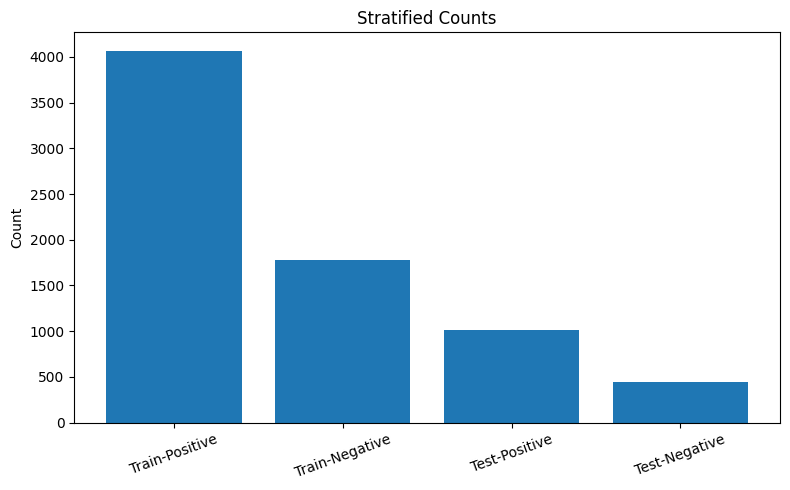

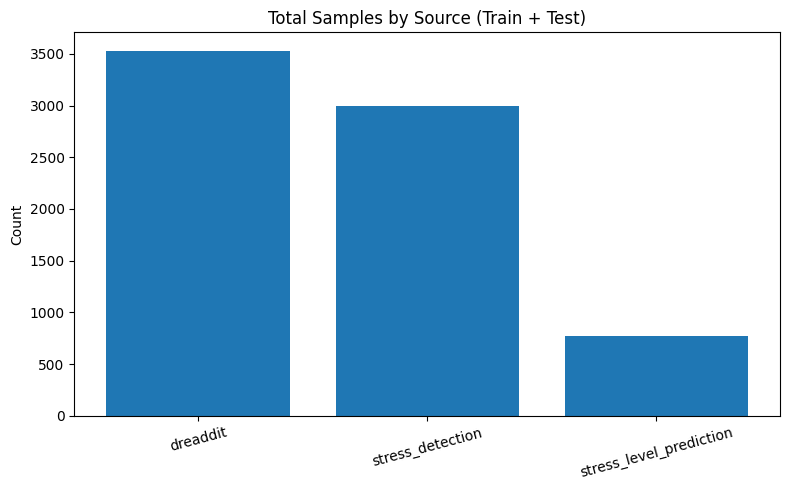

Stratified counts:
  Train-Positive: 4066
  Train-Negative: 1778
  Test-Positive : 1016
  Test-Negative : 445

Source totals (Train + Test):
  dreaddit               : 3532
  stress_detection       : 3000
  stress_level_prediction: 773


In [ ]:
# Using the provided counts directly and plotting two bar charts with matplotlib (Colab-compatible).
import matplotlib.pyplot as plt

# ---------- Provided counts ----------
# Stratified counts
train_pos = 4066
train_neg = 1778
test_pos  = 1016
test_neg  = 445

# Per-source counts (train + test totals)
dreaddit_total = 2823 + 709
stress_detection_total = 2388 + 612
stress_level_prediction_total = 633 + 140

# ---------- 1) Bar chart: stratified data ----------
labels1 = ["Train-Positive", "Train-Negative", "Test-Positive", "Test-Negative"]
values1 = [train_pos, train_neg, test_pos, test_neg]

plt.figure(figsize=(8, 5))
plt.bar(labels1, values1)
plt.title("Stratified Counts")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# ---------- 2) Bar chart: source totals ----------
labels2 = ["dreaddit", "stress_detection", "stress_level_prediction"]
values2 = [dreaddit_total, stress_detection_total, stress_level_prediction_total]

plt.figure(figsize=(8, 5))
plt.bar(labels2, values2)
plt.title("Total Samples by Source (Train + Test)")
plt.ylabel("Count")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Also print the exact numbers for reference
print("Stratified counts:")
print(f"  Train-Positive: {train_pos}")
print(f"  Train-Negative: {train_neg}")
print(f"  Test-Positive : {test_pos}")
print(f"  Test-Negative : {test_neg}")
print("\nSource totals (Train + Test):")
print(f"  dreaddit               : {dreaddit_total}")
print(f"  stress_detection       : {stress_detection_total}")
print(f"  stress_level_prediction: {stress_level_prediction_total}")


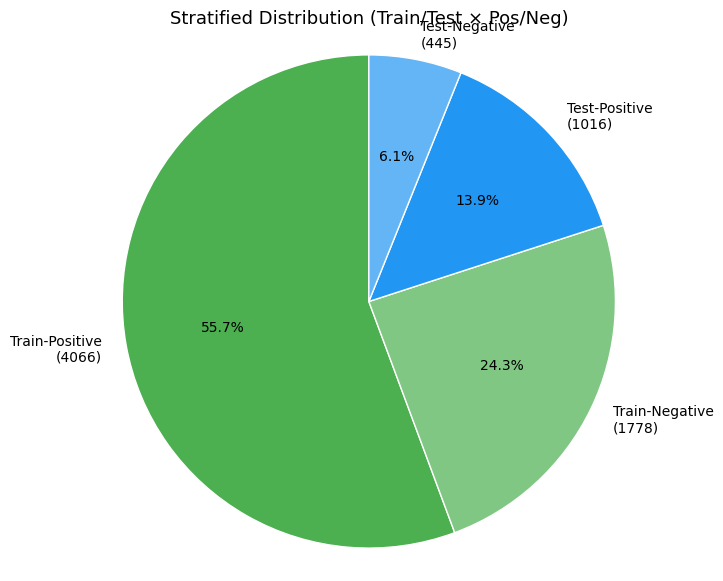

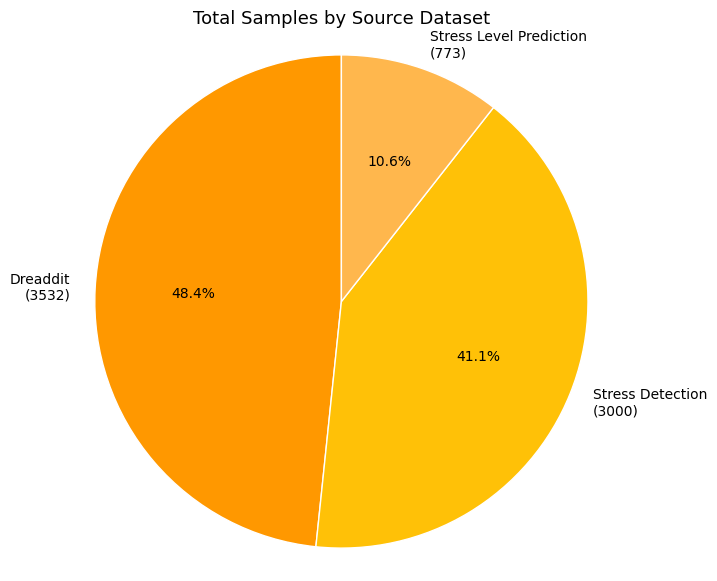

In [ ]:
# ==============================
# Pie Charts for Stratified Data
# ==============================

import matplotlib.pyplot as plt

# ---------- Provided counts ----------
train_pos = 4066
train_neg = 1778
test_pos  = 1016
test_neg  = 445

dreaddit_total = 2823 + 709
stress_detection_total = 2388 + 612
stress_level_prediction_total = 633 + 140

# ---------- 1) Pie Chart: Stratified Data ----------
strat_labels = ["Train-Positive", "Train-Negative", "Test-Positive", "Test-Negative"]
strat_values = [train_pos, train_neg, test_pos, test_neg]
strat_colors = ["#4CAF50", "#81C784", "#2196F3", "#64B5F6"]

plt.figure(figsize=(7, 7))
plt.pie(
    strat_values,
    labels=[f"{l}\n({v})" for l, v in zip(strat_labels, strat_values)],
    autopct="%1.1f%%",
    startangle=90,
    colors=strat_colors,
    wedgeprops={"edgecolor": "white"},
)
plt.title("Stratified Distribution (Train/Test × Pos/Neg)", fontsize=13)
plt.axis("equal")
plt.show()

# ---------- 2) Pie Chart: Source Totals ----------
source_labels = ["Dreaddit", "Stress Detection", "Stress Level Prediction"]
source_values = [dreaddit_total, stress_detection_total, stress_level_prediction_total]
source_colors = ["#FF9800", "#FFC107", "#FFB74D"]

plt.figure(figsize=(7, 7))
plt.pie(
    source_values,
    labels=[f"{l}\n({v})" for l, v in zip(source_labels, source_values)],
    autopct="%1.1f%%",
    startangle=90,
    colors=source_colors,
    wedgeprops={"edgecolor": "white"},
)
plt.title("Total Samples by Source Dataset", fontsize=13)
plt.axis("equal")
plt.show()


In [ ]:
# ==============================================================
# Train & Test on combined_strat_{train,test}.jsonl
# Writes a single CSV: results_combined_strat.csv
# Saves best artifacts under models/combined_strat/best/
# Includes tokenizer_shim + inference.py for safe loading later
# ==============================================================

# Optional (Colab):
# !pip -q install jieba joblib imbalanced-learn

import os, re, json, math, joblib, numpy as np, pandas as pd
from pathlib import Path
from typing import Any, Dict, List, Tuple
from collections import Counter

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, confusion_matrix, roc_auc_score
)

# Oversampling (optional)
try:
    from imblearn.over_sampling import RandomOverSampler
    HAS_IMB = True
except Exception:
    HAS_IMB = False

# ----------------------- Paths -----------------------
try:
    from google.colab import drive
    drive.mount("/content/drive")
    COLAB = True
except Exception:
    COLAB = False

if COLAB:
    DATA_ROOT = "/content/drive/My Drive/Rice University/25fall/ELEC509/Final Project/Dataset/Stress_final"
else:
    # Fallback for local runs, change if needed
    DATA_ROOT = "/Users/tanlinrui/Library/CloudStorage/GoogleDrive-tanlr20030801@gmail.com/My Drive/Rice University/25fall/ELEC509/Final Project/Dataset/Stress_final"

ROOT = Path(DATA_ROOT)
TRAIN_FP = ROOT / "combined_strat_train.jsonl"
TEST_FP  = ROOT / "combined_strat_test.jsonl"
EN_SW    = ROOT / "english_stopwords.txt"
CN_SW    = ROOT / "chinese_stopwords.txt"

OUT_CSV  = ROOT / "results_combined_strat.csv"
MODELS_DIR = ROOT / "models" / "combined_strat" / "best"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# ----------------------- Stopwords -----------------------
def load_stopwords(fp: Path, lowercase=False) -> set:
    if not fp.exists():
        raise FileNotFoundError(f"Missing stopwords: {fp}")
    words = []
    with fp.open("r", encoding="utf-8", errors="ignore") as f:
        for ln in f:
            ln = ln.strip()
            if ln and not ln.startswith("#"):
                words.append(ln.lower() if lowercase else ln)
    return set(words)

EN_STOP = load_stopwords(EN_SW, lowercase=True)
CN_STOP = load_stopwords(CN_SW, lowercase=False)

# ----------------------- Tokenizer (training-time) -----------------------
try:
    import jieba
    HAS_JIEBA = True
except Exception:
    HAS_JIEBA = False

CJK_RE = re.compile(r"[\u4e00-\u9fff]")
TOKEN_RE_EN = re.compile(r"[A-Za-z]+(?:'[A-Za-z]+)?")
FALLBACK_WORD_RE = re.compile(r"\w+")
NUM_PUNC_RE = re.compile(r"^[\W_]+$")

def mixed_tokenize(text: str) -> List[str]:
    text = str(text).strip()
    toks: List[str] = []
    # English tokens
    en = [w.lower() for w in TOKEN_RE_EN.findall(text)]
    en = [w for w in en if w not in EN_STOP]
    toks.extend(en)
    # Chinese tokens
    if CJK_RE.search(text):
        if HAS_JIEBA:
            cn = [w.strip() for w in jieba.cut(text, cut_all=False) if w.strip()]
        else:
            cn = [ch for ch in text if CJK_RE.match(ch)]
        cn = [w for w in cn if w not in CN_STOP and not NUM_PUNC_RE.match(w)]
        toks.extend(cn)
    # Fallback
    if not toks:
        toks = [t for t in FALLBACK_WORD_RE.findall(text.lower()) if t not in EN_STOP]
    return toks

# ----------------------- Data Loading -----------------------
def load_jsonl_df(path: Path) -> pd.DataFrame:
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for ln in f:
            ln = ln.strip()
            if not ln:
                continue
            try:
                rows.append(json.loads(ln))
            except json.JSONDecodeError:
                continue
    if not rows:
        raise ValueError(f"No data in {path}")
    df = pd.DataFrame(rows)
    # required fields: text, label, source_dataset, original_id
    df["text"] = df["text"].astype(str)
    df["label"] = pd.to_numeric(df["label"], errors="coerce").fillna(0).astype(int)
    return df

train_df = load_jsonl_df(TRAIN_FP)
test_df  = load_jsonl_df(TEST_FP)

print("Train size / pos ratio:", len(train_df), f"{train_df['label'].mean():.3f}")
print("Test  size / pos ratio:", len(test_df),  f"{test_df['label'].mean():.3f}")
print("Train label counts:", Counter(train_df["label"].values))
print("Test  label counts:", Counter(test_df["label"].values))

# ----------------------- Previous running parameters -----------------------
VECTORIZER_GRID = [
    {"max_features": 20000, "min_df": 1},  # smaller vocab, faster, less overfit risk, recall may drop
    {"max_features": 40000, "min_df": 3},  # mid vocab, filters rare noise, balanced precision/recall
    {"max_features": 80000, "min_df": 5},  # large vocab, richer phrases, recall↑ but overfit/time↑
]
LR_GRID = [
    {"C": 0.5, "class_weight": "balanced"},                 # stronger reg, precision stable, recall may drop
    {"C": 1.0, "class_weight": "balanced"},                 # moderate reg, often best F1 on clean data
    {"C": 2.0, "class_weight": "balanced"},                 # weaker reg, recall↑ but overfit risk
    {"C": 1.0, "class_weight": {0: 1.0, 1: 2.0}},           # stress weight 2x, recall↑ precision↓
    {"C": 1.0, "class_weight": {0: 1.0, 1: 3.0}},           # stress weight 3x, recall↑↑ precision↓↓
    {"C": 2.0, "class_weight": {0: 1.0, 1: 3.0}},           # weak reg plus heavy weight, max recall, precision and AUC may drop
]
SVC_GRID = [
    {"C": 0.5, "class_weight": {0: 1.0, 1: 2.0}},           # softer margin, better generalization, recall↑ modest
    {"C": 1.0, "class_weight": {0: 1.0, 1: 2.0}},           # balanced tradeoff, often good F1
    {"C": 1.0, "class_weight": {0: 1.0, 1: 3.0}},           # more stress weight, recall↑ precision↓
    {"C": 2.0, "class_weight": {0: 1.0, 1: 3.0}},           # tight margin plus heavy weight, recall↑↑ precision and calibration may suffer
]
SAMPLERS = ["none", "ros"]  # "ros": oversamples positives, recall↑ precision↓, may overfit
THRESHOLDS = np.linspace(0.05, 0.95, 19)  # lower t favors recall, higher t favors precision, F1 peaks at a middle value

# ----------------------- Helpers -----------------------
def apply_sampling(X, y, sampler: str):
    if sampler == "ros":
        if not HAS_IMB:
            raise RuntimeError("imbalanced-learn not installed; remove 'ros' from SAMPLERS or pip install.")
        return RandomOverSampler(random_state=42).fit_resample(X, y)
    return X, y

def pick_best_threshold(y_true: np.ndarray, probs: np.ndarray) -> Tuple[float, Dict[str, float]]:
    best_t, best = 0.5, {"f1": -1.0}
    for t in THRESHOLDS:
        preds = (probs >= t).astype(int)
        prec, rec, f1, _ = precision_recall_fscore_support(y_true, preds, average="binary", zero_division=0)
        if f1 > best["f1"]:
            best_t = float(t)
            best = {"precision": float(prec), "recall": float(rec), "f1": float(f1)}
    return best_t, best

def vectorize(df_train: pd.DataFrame, df_test: pd.DataFrame, cfg: Dict[str, Any]):
    vec = TfidfVectorizer(
        analyzer="word",
        tokenizer=mixed_tokenize,
        ngram_range=(1, 4),
        max_features=cfg["max_features"],
        min_df=cfg["min_df"],
        dtype=np.float32
    )
    X_tr = vec.fit_transform(df_train["text"])
    X_te = vec.transform(df_test["text"])
    return vec, X_tr, X_te

def run_lr(X_tr, y_tr, X_val, y_val, X_test, y_test, cfg: Dict[str, Any]):
    clf = LogisticRegression(max_iter=3000, solver="lbfgs", n_jobs=-1, **cfg)
    clf.fit(X_tr, y_tr)
    val_probs = clf.predict_proba(X_val)[:, 1]
    t_star, valid_scores = pick_best_threshold(y_val, val_probs)
    test_probs = clf.predict_proba(X_test)[:, 1]
    y_hat = (test_probs >= t_star).astype(int)
    return clf, t_star, valid_scores, y_hat, test_probs

def run_svc_calib(X_tr, y_tr, X_val, y_val, X_test, y_test, cfg: Dict[str, Any]):
    base = LinearSVC(**cfg)
    clf = CalibratedClassifierCV(base, method="sigmoid", cv=3)
    clf.fit(X_tr, y_tr)
    val_probs = clf.predict_proba(X_val)[:, 1]
    t_star, valid_scores = pick_best_threshold(y_val, val_probs)
    test_probs = clf.predict_proba(X_test)[:, 1]
    y_hat = (test_probs >= t_star).astype(int)
    return clf, t_star, valid_scores, y_hat, test_probs

def evaluate(y_true: np.ndarray, y_hat: np.ndarray, probs: np.ndarray) -> Dict[str, Any]:
    acc = accuracy_score(y_true, y_hat)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_hat, average="binary", zero_division=0)
    try:
        auc = roc_auc_score(y_true, probs)
    except Exception:
        auc = float("nan")
    cm = confusion_matrix(y_true, y_hat)
    return {
        "accuracy": float(acc),
        "precision": float(prec),
        "recall": float(rec),
        "f1": float(f1),
        "auc": float(auc),
        "tn": int(cm[0,0]), "fp": int(cm[0,1]),
        "fn": int(cm[1,0]), "tp": int(cm[1,1]),
    }

def export_best(vec, clf, t_star: float, feature_count: int = 50):
    MODELS_DIR.mkdir(parents=True, exist_ok=True)
    joblib.dump(clf, MODELS_DIR / "classifier.joblib")
    joblib.dump(vec, MODELS_DIR / "tfidf_vectorizer.joblib")
    with open(MODELS_DIR / "inference_threshold.txt", "w") as f:
        f.write(str(t_star))

    # Optional: export top features if linear with coef_
    try:
        feature_names = np.array(vec.get_feature_names_out())
        coefs = clf.coef_[0]
        order = np.argsort(np.abs(coefs))[::-1][:feature_count]
        top_df = pd.DataFrame({
            "feature": feature_names[order],
            "coef": coefs[order],
            "abs_coef": np.abs(coefs[order]),
        })
        top_df.to_csv(MODELS_DIR / "top_features.csv", index=False)
        top_df.to_json(MODELS_DIR / "top_features.json", orient="records", force_ascii=False, indent=2)
    except Exception:
        pass

    # 1) tokenizer_shim.py matching training mixed_tokenize
    tokenizer_code = r'''# tokenizer_shim.py
import re
try:
    import jieba
    HAS_JIEBA = True
except Exception:
    HAS_JIEBA = False

EN_STOP = set()
CN_STOP = set()

CJK_RE = re.compile(r"[\u4e00-\u9fff]")
TOKEN_RE_EN = re.compile(r"[A-Za-z]+(?:'[A-Za-z]+)?")
FALLBACK_WORD_RE = re.compile(r"\w+")
NUM_PUNC_RE = re.compile(r"^[\W_]+$")

def mixed_tokenize(text):
    text = str(text).strip()
    toks = []
    en = [w.lower() for w in TOKEN_RE_EN.findall(text)]
    en = [w for w in en if w not in EN_STOP]
    toks.extend(en)
    if CJK_RE.search(text):
        if HAS_JIEBA:
            cn = [w.strip() for w in jieba.cut(text, cut_all=False) if w.strip()]
        else:
            cn = [ch for ch in text if CJK_RE.match(ch)]
        cn = [w for w in cn if w not in CN_STOP and not NUM_PUNC_RE.match(w)]
        toks.extend(cn)
    if not toks:
        toks = [t for t in FALLBACK_WORD_RE.findall(text.lower()) if t not in EN_STOP]
    return toks
'''
    with open(MODELS_DIR / "tokenizer_shim.py", "w", encoding="utf-8") as f:
        f.write(tokenizer_code)

    # 2) inference.py that injects mixed_tokenize into __main__ before unpickling
    inference_code = r'''# inference.py
import os, importlib.util, joblib

def _inject_mixed_tokenize(model_dir: str):
    import __main__ as _m
    if hasattr(_m, "mixed_tokenize"):
        return
    shim_path = os.path.join(model_dir, "tokenizer_shim.py")
    spec = importlib.util.spec_from_file_location("tokenizer_shim", shim_path)
    mod = importlib.util.module_from_spec(spec)
    assert spec is not None and spec.loader is not None
    spec.loader.exec_module(mod)  # type: ignore
    _m.mixed_tokenize = getattr(mod, "mixed_tokenize")

def predict_stress(text: str, model_dir: str, threshold: float | None = None):
    _inject_mixed_tokenize(model_dir)
    clf = joblib.load(os.path.join(model_dir, "classifier.joblib"))
    vec = joblib.load(os.path.join(model_dir, "tfidf_vectorizer.joblib"))

    thr_path = os.path.join(model_dir, "inference_threshold.txt")
    if threshold is None and os.path.exists(thr_path):
        try:
            with open(thr_path, "r") as f:
                threshold = float(f.read().strip())
        except Exception:
            threshold = 0.5
    if threshold is None:
        threshold = 0.5

    X = vec.transform([text])
    if hasattr(clf, "predict_proba"):
        prob = float(clf.predict_proba(X)[0, 1])
    else:
        import numpy as np
        score = float(clf.decision_function(X)[0])
        prob = 1.0 / (1.0 + np.exp(-score))

    return {
        "stress_probability": round(prob, 4),
        "prediction": "STRESS" if prob >= threshold else "CALM",
        "threshold": float(threshold),
    }
'''
    with open(MODELS_DIR / "inference.py", "w", encoding="utf-8") as f:
        f.write(inference_code)

# ----------------------- Build val split from TRAIN -----------------------
y_train = train_df["label"].values.astype(int)
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
idx_tr, idx_val = next(sss.split(train_df["text"], y_train))

# ----------------------- Run grid -----------------------
results = []
best = {"f1": -1.0}
best_payload = None

for vcfg in VECTORIZER_GRID:
    vec, X_train_full, X_test = vectorize(train_df, test_df, vcfg)
    X_tr, X_val = X_train_full[idx_tr], X_train_full[idx_val]
    y_tr, y_val = y_train[idx_tr], y_train[idx_val]
    y_test = test_df["label"].values.astype(int)

    for sampler in SAMPLERS:
        if sampler == "ros" and not HAS_IMB:
            continue
        X_tr_s, y_tr_s = apply_sampling(X_tr, y_tr, sampler)

        # Logistic Regression
        for lrc in LR_GRID:
            clf, t_star, v_scores, y_hat, test_probs = run_lr(X_tr_s, y_tr_s, X_val, y_val, X_test, y_test, lrc)
            metrics = evaluate(y_test, y_hat, test_probs)
            row = {
                "dataset": "combined_strat",
                "vectorizer_max_features": vcfg["max_features"],
                "vectorizer_min_df": vcfg["min_df"],
                "sampler": sampler,
                "model": "LogisticRegression",
                "params": json.dumps(lrc),
                "val_f1": round(v_scores["f1"], 4),
                "val_precision": round(v_scores["precision"], 4),
                "val_recall": round(v_scores["recall"], 4),
                "thr": round(t_star, 3),
                "test_accuracy": round(metrics["accuracy"], 4),
                "test_precision": round(metrics["precision"], 4),
                "test_recall": round(metrics["recall"], 4),
                "test_f1": round(metrics["f1"], 4),
                "test_auc": round(metrics["auc"], 4) if not math.isnan(metrics["auc"]) else None,
                "tn": metrics["tn"], "fp": metrics["fp"], "fn": metrics["fn"], "tp": metrics["tp"],
            }
            results.append(row)
            if row["test_f1"] > best["f1"]:
                best = {"f1": row["test_f1"]}
                best_payload = ("lr", vcfg, sampler, lrc, vec, clf, t_star)

        # LinearSVC + Calibration
        for svcc in SVC_GRID:
            clf, t_star, v_scores, y_hat, test_probs = run_svc_calib(X_tr_s, y_tr_s, X_val, y_val, X_test, y_test, svcc)
            metrics = evaluate(y_test, y_hat, test_probs)
            row = {
                "dataset": "combined_strat",
                "vectorizer_max_features": vcfg["max_features"],
                "vectorizer_min_df": vcfg["min_df"],
                "sampler": sampler,
                "model": "LinearSVC+Calib",
                "params": json.dumps(svcc),
                "val_f1": round(v_scores["f1"], 4),
                "val_precision": round(v_scores["precision"], 4),
                "val_recall": round(v_scores["recall"], 4),
                "thr": round(t_star, 3),
                "test_accuracy": round(metrics["accuracy"], 4),
                "test_precision": round(metrics["precision"], 4),
                "test_recall": round(metrics["recall"], 4),
                "test_f1": round(metrics["f1"], 4),
                "test_auc": round(metrics["auc"], 4) if not math.isnan(metrics["auc"]) else None,
                "tn": metrics["tn"], "fp": metrics["fp"], "fn": metrics["fn"], "tp": metrics["tp"],
            }
            results.append(row)
            if row["test_f1"] > best["f1"]:
                best = {"f1": row["test_f1"]}
                best_payload = ("svc", vcfg, sampler, svcc, vec, clf, t_star)

# ----------------------- Save CSV -----------------------
res_df = pd.DataFrame(results).sort_values(
    by=["test_f1", "val_f1", "test_recall", "test_precision"],
    ascending=[False, False, False, False]
).reset_index(drop=True)
res_df.to_csv(OUT_CSV, index=False)
print(f"\nSaved results to: {OUT_CSV}")

# ----------------------- Save best artifacts -----------------------
if best_payload is not None:
    _, vcfg, sampler, params, vec, clf, t_star = best_payload
    export_best(vec, clf, t_star, feature_count=50)
    print("\nBest row:")
    print(res_df.iloc[0][[
        "dataset","model","params","sampler","vectorizer_max_features",
        "vectorizer_min_df","thr","test_f1","test_precision","test_recall","test_accuracy"
    ]])
    print(f"\nArtifacts saved under: {MODELS_DIR}")
else:
    print("No best payload found.")


Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:44: SyntaxWarning: invalid escape sequence '\.'
  re_han_default = re.compile("([\u4E00-\u9FD5a-zA-Z0-9+#&\._%\-]+)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:46: SyntaxWarning: invalid escape sequence '\s'
  re_skip_default = re.compile("(\r\n|\s)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/finalseg/__init__.py:78: SyntaxWarning: invalid escape sequence '\.'
  re_skip = re.compile("([a-zA-Z0-9]+(?:\.\d+)?%?)")


Train size / pos ratio: 5844 0.696
Test  size / pos ratio: 1461 0.695
Train label counts: Counter({np.int64(1): 4066, np.int64(0): 1778})
Test  label counts: Counter({np.int64(1): 1016, np.int64(0): 445})


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(



Saved results to: /content/drive/My Drive/Rice University/25fall/ELEC509/Final Project/Dataset/Stress_final/results_combined_strat.csv

Best row:
dataset                                                      combined_strat
model                                                       LinearSVC+Calib
params                     {"C": 0.5, "class_weight": {"0": 1.0, "1": 2.0}}
sampler                                                                none
vectorizer_max_features                                               40000
vectorizer_min_df                                                         3
thr                                                                    0.45
test_f1                                                              0.8619
test_precision                                                       0.7937
test_recall                                                          0.9429
test_accuracy                                                        0.7899
Name: 0, dtype: o